# Figure 1 and Supplementary Figure S1: ICU cohort overview

This notebook generates a publication-style main Figure 1 and a supplementary cohort-characteristics panel for the ICU mortality prediction project.

Design choices:
- Main Figure 1 is kept compact as a three-panel overview: external validation setup, mortality imbalance, and key cohort/data characteristics.
- Supplementary Figure S1 contains remaining cohort details that are useful for reviewers but too detailed for the main figure.
- Figure width is fixed at 170 mm for manuscript formatting.
- Only panel letters are bolded in the figure text.

In [1]:
# ============================================================
# 1. Imports and publication-style settings
# ============================================================
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import patches
from matplotlib.patches import FancyArrowPatch
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

warnings.filterwarnings("ignore")

# Physical size for a two-column manuscript figure.
FIG_WIDTH_MM = 170
FIG_WIDTH_IN = FIG_WIDTH_MM / 25.4

DPI = 600

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans", "Liberation Sans"],
    "font.size": 8.5,
    "axes.titlesize": 9.5,
    "axes.labelsize": 8.5,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})

# Colorblind-friendly palette used consistently across the figure.
COLORS = {
    "dev": "#9EB6CF",
    "test": "#F2BE7E",
    "survived": "#76B7B2",
    "died": "#E15759",
    "female": "#B07AA1",
    "male": "#59A14F",
    "unknown": "#BAB0AC",
    "blue_fill": "#EAF3FA",
    "blue_edge": "#C5D8EA",
    "orange_fill": "#FFF3E6",
    "orange_edge": "#F2C99E",
    "gray": "#4D4D4D",
    "icu_ccu": "#A67C64",
    "icu_csru": "#EDC948",
    "icu_micu": "#59A14F",
    "icu_sicu": "#B07AA1",
}

SPLIT_LABELS = {
    "train": "Development\nA+B",
    "test": "External test\nC",
}

ICU_SHORT = {
    "Coronary Care Unit": "CCU",
    "Cardiac Surgery Recovery Unit": "CSRU",
    "Medical ICU": "Medical\nICU",
    "Surgical ICU": "Surgical\nICU",
}

ICU_ORDER = [
    "Coronary Care Unit",
    "Cardiac Surgery Recovery Unit",
    "Medical ICU",
    "Surgical ICU",
]

ICU_COLORS = {
    "Coronary Care Unit": COLORS["icu_ccu"],
    "Cardiac Surgery Recovery Unit": COLORS["icu_csru"],
    "Medical ICU": COLORS["icu_micu"],
    "Surgical ICU": COLORS["icu_sicu"],
}


In [2]:
# ============================================================
# 2. Paths and data loading
# ============================================================
def resolve_project_root() -> Path:
    """Return the project root. The notebook is expected to run from code/ or project root."""
    cwd = Path.cwd().resolve()
    if cwd.name.lower() == "code":
        return cwd.parent
    return cwd

PROJECT_ROOT = resolve_project_root()
OUTPUT_DIR = PROJECT_ROOT / "output"
FIG_DIR = OUTPUT_DIR / "figures" / "figure1_cohort_overview"
FIG_DIR.mkdir(parents=True, exist_ok=True)


def find_existing_file(candidates):
    """Find the first existing file among candidate paths."""
    for p in candidates:
        p = Path(p)
        if p.exists():
            return p
    raise FileNotFoundError("None of the candidate files exist:\n" + "\n".join(map(str, candidates)))

cohort_dataset_file = find_existing_file([
    OUTPUT_DIR / "cohort_distribution_dataset.csv",
    OUTPUT_DIR / "cohort_distribution_dataset(1).csv",
    PROJECT_ROOT / "cohort_distribution_dataset.csv",
    PROJECT_ROOT / "cohort_distribution_dataset(1).csv",
    Path("/mnt/data/cohort_distribution_dataset.csv"),
    Path("/mnt/data/cohort_distribution_dataset(1).csv"),
])

summary_table_file = find_existing_file([
    OUTPUT_DIR / "cohort_summary_table_for_figure1.csv",
    PROJECT_ROOT / "cohort_summary_table_for_figure1.csv",
    Path("/mnt/data/cohort_summary_table_for_figure1.csv"),
])

df = pd.read_csv(cohort_dataset_file)
summary_df = pd.read_csv(summary_table_file)

# Ensure a stable cohort order.
df["split"] = pd.Categorical(df["split"], categories=["train", "test"], ordered=True)
df["source_set"] = pd.Categorical(df["source_set"], categories=["A", "B", "C"], ordered=True)

print(f"Loaded cohort dataset: {cohort_dataset_file}")
print(f"Loaded summary table:   {summary_table_file}")
print(f"Dataset shape: {df.shape}")
print(summary_df)


Loaded cohort dataset: C:\Users\junse\Documents\research\IUBDC 2026\output\cohort_distribution_dataset.csv
Loaded summary table:   C:\Users\junse\Documents\research\IUBDC 2026\output\cohort_summary_table_for_figure1.csv
Dataset shape: (12000, 24)
   split  n_patients mortality_n_percent     age_median_iqr female_n_percent  \
0  train        8000       1,122 (14.0%)  67.0 [53.0, 78.0]    3,493 (43.7%)   
1   test        4000         585 (14.6%)  67.0 [54.0, 78.0]    1,768 (44.2%)   

  male_n_percent dynamic_measurements_median_iqr dynamic_parameters_median_iqr  
0  4,499 (56.2%)            392.0 [331.0, 468.0]             26.0 [23.0, 29.0]  
1  2,228 (55.7%)            390.0 [330.0, 469.0]             26.0 [23.0, 29.0]  


In [3]:
# ============================================================
# 3. Helper functions
# ============================================================
def save_figure(fig, stem, out_dir=FIG_DIR):
    """Save figure in manuscript-ready raster and vector formats.

    Important: bbox_inches='tight' is intentionally not used because it can
    change the exported physical width away from the requested 170 mm.
    """
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    paths = {}
    for ext in ["png", "pdf", "svg"]:
        path = out_dir / f"{stem}.{ext}"
        fig.savefig(path, dpi=DPI, facecolor="white")
        paths[ext] = path
    return paths


def add_panel_label(fig, x, y, label):
    """Add a bold panel letter in figure coordinates."""
    fig.text(x, y, label, fontsize=13, fontweight="bold", ha="left", va="top")


def clean_axes(ax, grid_axis="y"):
    """Apply a clean manuscript style to an axis."""
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    if grid_axis:
        ax.grid(axis=grid_axis, color="#E6E6E6", linewidth=0.8)
        ax.set_axisbelow(True)


def add_axis_panel_label(ax, label, x=-0.16, y=1.13):
    """Add a bold panel letter relative to a subplot."""
    ax.text(x, y, label, transform=ax.transAxes, fontsize=13, fontweight="bold",
            ha="left", va="top", clip_on=False)


def draw_validation_setup(ax):
    """Panel A: external validation setup schematic."""
    ax.set_axis_off()
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    ax.text(0.06, 0.95, "External validation setup", ha="left", va="top", fontsize=10.5)

    def box(x, y, w, h, text, fill, edge):
        rect = patches.Rectangle((x, y), w, h, facecolor=fill, edgecolor=edge, linewidth=1.2)
        ax.add_patch(rect)
        ax.text(x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=9)
        return rect

    box(0.06, 0.62, 0.23, 0.17, "Set A\nn=4,000", COLORS["blue_fill"], COLORS["blue_edge"])
    box(0.06, 0.40, 0.23, 0.17, "Set B\nn=4,000", COLORS["blue_fill"], COLORS["blue_edge"])
    box(0.58, 0.51, 0.37, 0.21, "Model development\nA+B, n=8,000", COLORS["blue_fill"], COLORS["blue_edge"])

    box(0.06, 0.14, 0.23, 0.17, "Set C\nn=4,000", COLORS["orange_fill"], COLORS["orange_edge"])
    box(0.58, 0.09, 0.37, 0.21, "External test\nC, n=4,000", COLORS["orange_fill"], COLORS["orange_edge"])

    arrow_kw = dict(arrowstyle="->", mutation_scale=12, lw=1.1, color=COLORS["gray"])
    ax.add_patch(FancyArrowPatch((0.31, 0.705), (0.565, 0.62), **arrow_kw))
    ax.add_patch(FancyArrowPatch((0.31, 0.485), (0.565, 0.61), **arrow_kw))
    ax.add_patch(FancyArrowPatch((0.31, 0.225), (0.565, 0.195), **arrow_kw))


def plot_mortality_by_split(ax):
    """Panel B: mortality distribution in development and external test cohorts."""
    counts = (
        df.groupby(["split", "mortality_label"], observed=True)
          .size()
          .unstack(fill_value=0)
          .reindex(["train", "test"])
    )
    counts = counts[["Survived", "Died"]]
    totals = counts.sum(axis=1)

    x = np.arange(2)
    survived_pct = counts["Survived"].values / totals.values * 100
    died_pct = counts["Died"].values / totals.values * 100

    ax.bar(x, survived_pct, width=0.62, color=COLORS["survived"], edgecolor="white", linewidth=0.8, label="Survived")
    ax.bar(x, died_pct, bottom=survived_pct, width=0.62, color=COLORS["died"], edgecolor="white", linewidth=0.8, label="Died")

    for i, split in enumerate(["train", "test"]):
        deaths = int(counts.loc[split, "Died"])
        total = int(totals.loc[split])
        ax.text(i, survived_pct[i] / 2, f"{survived_pct[i]:.1f}%", ha="center", va="center", color="white", fontsize=8.5)
        ax.text(i, survived_pct[i] + died_pct[i] / 2, f"{died_pct[i]:.1f}%\n{deaths:,}/{total:,}", ha="center", va="center", color="white", fontsize=8)

    ax.set_title("Mortality outcome", fontweight="normal", pad=3)
    ax.set_ylabel("Patients (%)")
    ax.set_xticks(x)
    ax.set_xticklabels([SPLIT_LABELS["train"], SPLIT_LABELS["test"]])
    ax.set_ylim(0, 100)
    ax.set_yticks([0, 25, 50, 75, 100])
    clean_axes(ax)
    ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.20), ncol=2, handlelength=0.9, columnspacing=0.8, handletextpad=0.35)


def plot_two_group_boxplot(ax, column, title, ylabel, ylim=None, showfliers=False):
    """Draw a two-cohort boxplot with consistent styling."""
    data = [
        df.loc[df["split"] == "train", column].dropna().values,
        df.loc[df["split"] == "test", column].dropna().values,
    ]
    bp = ax.boxplot(
        data,
        patch_artist=True,
        widths=0.46,
        showfliers=showfliers,
        medianprops=dict(color="black", linewidth=1.0),
        boxprops=dict(linewidth=0.9, color=COLORS["gray"]),
        whiskerprops=dict(linewidth=0.9, color=COLORS["gray"]),
        capprops=dict(linewidth=0.9, color=COLORS["gray"]),
    )
    for patch, color in zip(bp["boxes"], [COLORS["dev"], COLORS["test"]]):
        patch.set_facecolor(color)
        patch.set_alpha(0.85)
    ax.set_title(title, fontweight="normal", pad=3)
    ax.set_ylabel(ylabel)
    ax.set_xticks([1, 2])
    ax.set_xticklabels([SPLIT_LABELS["train"], SPLIT_LABELS["test"]])
    if ylim is not None:
        ax.set_ylim(*ylim)
    clean_axes(ax)


def plot_icu_distribution(ax):
    """Panel C middle: ICU admission type distribution."""
    counts = (
        df.groupby(["split", "ICUType_label"], observed=True)
          .size()
          .unstack(fill_value=0)
          .reindex(["train", "test"])
    )
    counts = counts.reindex(columns=ICU_ORDER, fill_value=0)
    totals = counts.sum(axis=1)
    x = np.arange(2)
    bottoms = np.zeros(2)

    for cat in ICU_ORDER:
        vals = counts[cat].values
        pct = vals / totals.values * 100
        ax.bar(x, pct, bottom=bottoms, width=0.62, color=ICU_COLORS[cat], edgecolor="white", linewidth=0.8, label=ICU_SHORT[cat].replace("\n", " "))
        for i, p in enumerate(pct):
            if p >= 8:
                label = f"{ICU_SHORT[cat]}\n{p:.0f}%" if i == 0 else f"{p:.0f}%"
                ax.text(i, bottoms[i] + p / 2, label, ha="center", va="center", color="white", fontsize=7.5, linespacing=0.9)
        bottoms += pct

    ax.set_title("ICU admission type", fontweight="normal", pad=3)
    ax.set_ylabel("Patients (%)")
    ax.set_xticks(x)
    ax.set_xticklabels([SPLIT_LABELS["train"], SPLIT_LABELS["test"]])
    ax.set_ylim(0, 100)
    ax.set_yticks([0, 25, 50, 75, 100])
    clean_axes(ax)


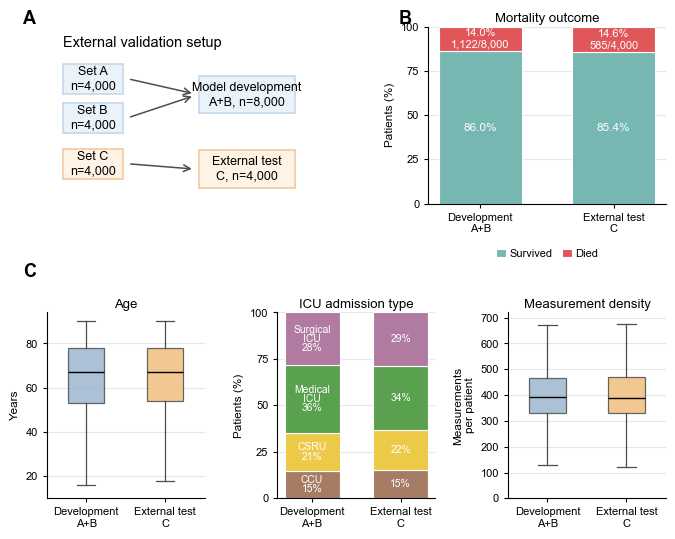

{'png': WindowsPath('C:/Users/junse/Documents/research/IUBDC 2026/output/figures/figure1_cohort_overview/Figure1_cohort_overview_ABC_170mm_final.png'),
 'pdf': WindowsPath('C:/Users/junse/Documents/research/IUBDC 2026/output/figures/figure1_cohort_overview/Figure1_cohort_overview_ABC_170mm_final.pdf'),
 'svg': WindowsPath('C:/Users/junse/Documents/research/IUBDC 2026/output/figures/figure1_cohort_overview/Figure1_cohort_overview_ABC_170mm_final.svg')}

In [4]:
# ============================================================
# 4. Main Figure 1: compact manuscript overview, 170 mm width
# ============================================================
def make_main_figure():
    fig = plt.figure(figsize=(FIG_WIDTH_IN, 5.55), facecolor="white")
    outer = GridSpec(
        2, 2,
        figure=fig,
        height_ratios=[1.00, 1.05],
        width_ratios=[1.10, 1.00],
        hspace=0.60,
        wspace=0.48,
        left=0.060,
        right=0.985,
        top=0.955,
        bottom=0.105,
    )

    # A. External validation setup.
    ax_a = fig.add_subplot(outer[0, 0])
    draw_validation_setup(ax_a)

    # B. Mortality outcome.
    ax_b = fig.add_subplot(outer[0, 1])
    plot_mortality_by_split(ax_b)

    # C. Key cohort and data characteristics.
    gs_c = GridSpecFromSubplotSpec(1, 3, subplot_spec=outer[1, :], wspace=0.46)
    ax_c1 = fig.add_subplot(gs_c[0, 0])
    ax_c2 = fig.add_subplot(gs_c[0, 1])
    ax_c3 = fig.add_subplot(gs_c[0, 2])

    plot_two_group_boxplot(ax_c1, "Age", "Age", "Years", ylim=(10, 94), showfliers=False)
    plot_icu_distribution(ax_c2)
    plot_two_group_boxplot(ax_c3, "n_dynamic_measurements", "Measurement density", "Measurements\nper patient", ylim=(0, 720), showfliers=False)

    # Panel labels. These are the only bold text elements in the figure.
    add_panel_label(fig, 0.025, 0.985, "A")
    add_panel_label(fig, 0.585, 0.985, "B")
    add_panel_label(fig, 0.025, 0.530, "C")

    return fig

main_fig = make_main_figure()
main_paths = save_figure(main_fig, "Figure1_cohort_overview_ABC_170mm_final")
plt.show()
main_paths


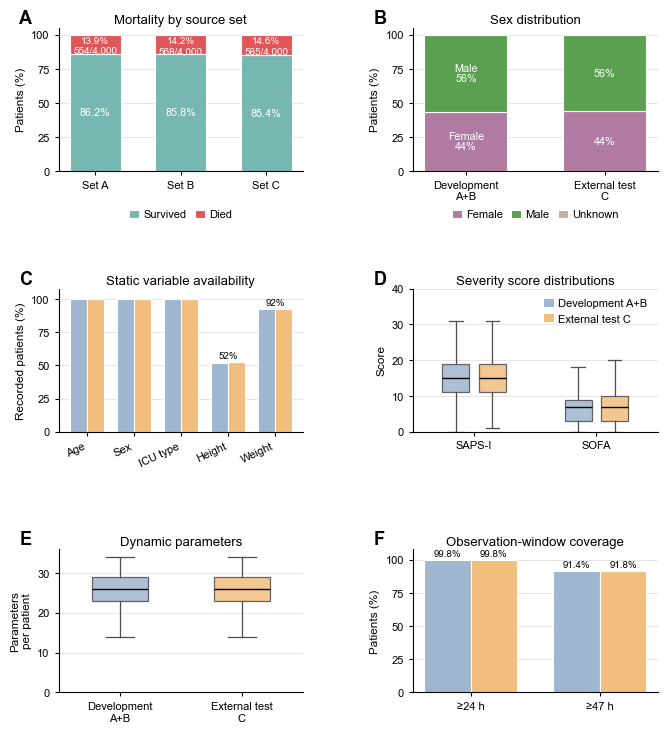

{'png': WindowsPath('C:/Users/junse/Documents/research/IUBDC 2026/output/figures/figure1_cohort_overview/Supplementary_FigureS1_cohort_characteristics_170mm.png'),
 'pdf': WindowsPath('C:/Users/junse/Documents/research/IUBDC 2026/output/figures/figure1_cohort_overview/Supplementary_FigureS1_cohort_characteristics_170mm.pdf'),
 'svg': WindowsPath('C:/Users/junse/Documents/research/IUBDC 2026/output/figures/figure1_cohort_overview/Supplementary_FigureS1_cohort_characteristics_170mm.svg')}

In [5]:
# ============================================================
# 5. Supplementary Figure S1: remaining cohort characteristics
# ============================================================
def plot_mortality_by_source_set(ax):
    counts = (
        df.groupby(["source_set", "mortality_label"], observed=True)
          .size()
          .unstack(fill_value=0)
          .reindex(["A", "B", "C"])
    )
    counts = counts[["Survived", "Died"]]
    totals = counts.sum(axis=1)
    x = np.arange(3)
    survived_pct = counts["Survived"].values / totals.values * 100
    died_pct = counts["Died"].values / totals.values * 100

    ax.bar(x, survived_pct, width=0.60, color=COLORS["survived"], edgecolor="white", linewidth=0.8, label="Survived")
    ax.bar(x, died_pct, bottom=survived_pct, width=0.60, color=COLORS["died"], edgecolor="white", linewidth=0.8, label="Died")

    for i, source in enumerate(["A", "B", "C"]):
        deaths = int(counts.loc[source, "Died"])
        total = int(totals.loc[source])
        ax.text(i, survived_pct[i] + died_pct[i] / 2 - 1.0, f"{died_pct[i]:.1f}%\n{deaths:,}/{total:,}", ha="center", va="center", color="white", fontsize=7.2)
        ax.text(i, survived_pct[i] / 2, f"{survived_pct[i]:.1f}%", ha="center", va="center", color="white", fontsize=7.8)

    ax.set_title("Mortality by source set", fontweight="normal", pad=3)
    ax.set_ylabel("Patients (%)")
    ax.set_xticks(x)
    ax.set_xticklabels(["Set A", "Set B", "Set C"])
    ax.set_ylim(0, 105)
    ax.set_yticks([0, 25, 50, 75, 100])
    clean_axes(ax)
    ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.20), ncol=2, handlelength=0.9, columnspacing=0.8, handletextpad=0.35)


def plot_sex_distribution(ax):
    counts = (
        df.groupby(["split", "Gender_label"], observed=True)
          .size()
          .unstack(fill_value=0)
          .reindex(["train", "test"])
    )
    order = ["Female", "Male", "Unknown"]
    counts = counts.reindex(columns=order, fill_value=0)
    category_colors = {"Female": COLORS["female"], "Male": COLORS["male"], "Unknown": COLORS["unknown"]}

    totals = counts.sum(axis=1)
    x = np.arange(2)
    bottoms = np.zeros(2)
    for cat in order:
        vals = counts[cat].values
        pct = vals / totals.values * 100
        ax.bar(x, pct, bottom=bottoms, width=0.60, color=category_colors[cat], edgecolor="white", linewidth=0.8, label=cat)
        for i, p in enumerate(pct):
            if p >= 5:
                ax.text(i, bottoms[i] + p / 2, f"{cat}\n{p:.0f}%" if i == 0 else f"{p:.0f}%", ha="center", va="center", color="white", fontsize=7.8, linespacing=0.9)
        bottoms += pct

    ax.set_title("Sex distribution", fontweight="normal", pad=3)
    ax.set_ylabel("Patients (%)")
    ax.set_xticks(x)
    ax.set_xticklabels([SPLIT_LABELS["train"], SPLIT_LABELS["test"]])
    ax.set_ylim(0, 105)
    ax.set_yticks([0, 25, 50, 75, 100])
    clean_axes(ax)
    ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.20), ncol=3, handlelength=0.9, columnspacing=0.8, handletextpad=0.35)


def plot_static_availability(ax):
    variables = [
        ("Age", "Age"),
        ("Gender", "Sex"),
        ("ICUType", "ICU type"),
        ("Height", "Height"),
        ("Weight", "Weight"),
    ]
    splits = ["train", "test"]
    values = []
    for split in splits:
        row = []
        sub = df[df["split"] == split]
        for col, _ in variables:
            valid = sub[col].notna()
            if pd.api.types.is_numeric_dtype(sub[col]):
                valid = valid & (sub[col] != -1)
            row.append(valid.mean() * 100)
        values.append(row)
    values = np.array(values)

    x = np.arange(len(variables))
    width = 0.36
    ax.bar(x - width / 2, values[0], width=width, color=COLORS["dev"], edgecolor="white", linewidth=0.8, label="Development A+B")
    ax.bar(x + width / 2, values[1], width=width, color=COLORS["test"], edgecolor="white", linewidth=0.8, label="External test C")

    for i in range(len(variables)):
        v_dev, v_test = values[0, i], values[1, i]
        # If rounded percentages are identical, annotate once to avoid text overlap.
        if max(v_dev, v_test) < 99.5 and round(v_dev) == round(v_test):
            ax.text(x[i], max(v_dev, v_test) + 1.5, f"{v_dev:.0f}%", ha="center", va="bottom", fontsize=7)
        else:
            for j, xpos in enumerate([x[i] - width / 2, x[i] + width / 2]):
                pct = values[j, i]
                if pct < 99.5:
                    ax.text(xpos, pct + 1.5, f"{pct:.0f}%", ha="center", va="bottom", fontsize=7)

    ax.set_title("Static variable availability", fontweight="normal", pad=3)
    ax.set_ylabel("Recorded patients (%)")
    ax.set_xticks(x)
    ax.set_xticklabels([name for _, name in variables], rotation=25, ha="right")
    ax.set_ylim(0, 108)
    ax.set_yticks([0, 25, 50, 75, 100])
    clean_axes(ax)


def plot_severity_scores(ax):
    metrics = [("SAPS-I", "SAPS-I"), ("SOFA", "SOFA")]
    positions = [0.85, 1.15, 1.85, 2.15]
    data = []
    colors = []
    for col, _ in metrics:
        for split, color in [("train", COLORS["dev"]), ("test", COLORS["test"] )]:
            vals = df.loc[(df["split"] == split) & (df[col].notna()) & (df[col] >= 0), col].values
            data.append(vals)
            colors.append(color)

    bp = ax.boxplot(
        data,
        positions=positions,
        widths=0.22,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color="black", linewidth=1.0),
        boxprops=dict(linewidth=0.9, color=COLORS["gray"]),
        whiskerprops=dict(linewidth=0.9, color=COLORS["gray"]),
        capprops=dict(linewidth=0.9, color=COLORS["gray"]),
    )
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.85)

    ax.set_title("Severity score distributions", fontweight="normal", pad=3)
    ax.set_ylabel("Score")
    ax.set_xticks([1, 2])
    ax.set_xticklabels(["SAPS-I", "SOFA"])
    ax.set_xlim(0.5, 2.5)
    ax.set_ylim(0, 40)
    clean_axes(ax)

    handles = [
        patches.Patch(facecolor=COLORS["dev"], edgecolor="none", label="Development A+B"),
        patches.Patch(facecolor=COLORS["test"], edgecolor="none", label="External test C"),
    ]
    ax.legend(handles=handles, frameon=False, loc="upper right", handlelength=0.9, handletextpad=0.35)


def plot_observation_window_coverage(ax):
    thresholds = [(24 * 60, "≥24 h"), (47 * 60, "≥47 h")]
    splits = [("train", "Development A+B", COLORS["dev"]), ("test", "External test C", COLORS["test"])]
    values = np.array([
        [((df.loc[df["split"] == split, "last_time_minutes"] >= th).mean() * 100) for th, _ in thresholds]
        for split, _, _ in splits
    ])

    x = np.arange(len(thresholds))
    width = 0.36
    for i, (split, label, color) in enumerate(splits):
        xpos = x + (-width / 2 if i == 0 else width / 2)
        ax.bar(xpos, values[i], width=width, color=color, edgecolor="white", linewidth=0.8, label=label)
        for xi, pct in zip(xpos, values[i]):
            ax.text(xi, pct + 1.2, f"{pct:.1f}%", ha="center", va="bottom", fontsize=7)

    ax.set_title("Observation-window coverage", fontweight="normal", pad=3)
    ax.set_ylabel("Patients (%)")
    ax.set_xticks(x)
    ax.set_xticklabels([label for _, label in thresholds])
    ax.set_ylim(0, 108)
    ax.set_yticks([0, 25, 50, 75, 100])
    clean_axes(ax)


def make_supplementary_figure():
    fig = plt.figure(figsize=(FIG_WIDTH_IN, 7.55), facecolor="white")
    gs = GridSpec(
        3, 2,
        figure=fig,
        hspace=0.82,
        wspace=0.45,
        left=0.090,
        right=0.985,
        top=0.955,
        bottom=0.075,
    )

    ax_a = fig.add_subplot(gs[0, 0])
    ax_b = fig.add_subplot(gs[0, 1])
    ax_c = fig.add_subplot(gs[1, 0])
    ax_d = fig.add_subplot(gs[1, 1])
    ax_e = fig.add_subplot(gs[2, 0])
    ax_f = fig.add_subplot(gs[2, 1])

    plot_mortality_by_source_set(ax_a)
    plot_sex_distribution(ax_b)
    plot_static_availability(ax_c)
    plot_severity_scores(ax_d)
    plot_two_group_boxplot(ax_e, "n_dynamic_parameters", "Dynamic parameters", "Parameters\nper patient", ylim=(0, 36), showfliers=False)
    plot_observation_window_coverage(ax_f)

    # Panel labels. These are the only bold text elements in the figure.
    for ax, label in zip([ax_a, ax_b, ax_c, ax_d, ax_e, ax_f], list("ABCDEF")):
        add_axis_panel_label(ax, label)

    return fig

supp_fig = make_supplementary_figure()
supp_paths = save_figure(supp_fig, "Supplementary_FigureS1_cohort_characteristics_170mm")
plt.show()
supp_paths


## Suggested captions

**Figure 1. Cohort construction and data characteristics for ICU mortality prediction.** A, Set A and Set B were combined as the model development cohort, while Set C was held out as an external test cohort. B, In-hospital mortality prevalence was similar between the development and external test cohorts, showing a consistently imbalanced binary outcome. C, Patient age, ICU admission type, and time-series measurement density were broadly comparable across cohorts, supporting the use of Set C as an external evaluation cohort for model discrimination and calibration.

**Supplementary Figure S1. Additional cohort characteristics and data-coverage summaries.** A, Mortality prevalence shown separately for Set A, Set B, and Set C. B, Sex distribution in the development and external test cohorts. C, Availability of static demographic and admission variables. D, Distributions of SAPS-I and SOFA severity scores, shown for cohort description only. E, Number of dynamic physiological and laboratory parameters recorded per patient. F, Proportion of patients with at least 24 hours and at least 47 hours of observation-window coverage.